In [26]:
%system free -m

['              total        used        free      shared  buff/cache   available',
 'Mem:         126104       73128       41349           4       11626       51891',
 'Swap:             0           0           0']

In [ ]:
import scanpy as sc
import numpy as np
import flowkit as fk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from preprocessing import read_flow
bld_dir = 'BLD_CD3_01DEC25'
bld_flow, bld_samples, bld_session = read_flow(bld_dir, "BLD")

Parameters: Index(['FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'AF-A',
       'Clec9a', 'LD_CD326', 'HLADR', 'CD56', 'Ki67', 'CD19', 'CD3', 'CD163',
       'CD33', 'CD16', 'IgE', 'CD1c', 'CD206', 'CD11b', 'CD127', 'CD117',
       'CCR3', 'CD49d', 'CD11c', 'CD169', 'CRTH2', 'FceRIa', 'CD103', 'CD45',
       'CD66b', 'IL33R', 'CD14', 'CD123', 'Time', 'tissue', 'sample_id',
       'condition', 'CD4'],
      dtype='object')


In [ ]:
bom_dir = "BOM_CD3_01DEC25"
bom_flow, bom_samples, bom_session = read_flow(bom_dir, "BOM")

Parameters: Index(['FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'AF-A',
       'Clec9a', 'LD_CD326', 'HLADR', 'CD56', 'Ki67', 'CD19', 'CD3', 'CD163',
       'CD33', 'CD4', 'CD16', 'IgE', 'CD1c', 'CD206', 'CD11b', 'CD127',
       'CD117', 'CCR3', 'CD49d', 'CD11c', 'CD169', 'CRTH2', 'FceRIa', 'CD103',
       'CD45', 'CD66b', 'IL33R', 'CD14', 'CD123', 'Time', 'tissue',
       'sample_id', 'condition', 'KI67'],
      dtype='object')


In [ ]:
jel_dir = 'JEL_CD3_01DEC25'
jel_flow, jel_samples, jel_session = read_flow(jel_dir, 'JEL')

In [ ]:
jlp_dir = 'JLP_CD3_01DEC25'
jlp_flow, jlp_samples, jlp_session = read_flow(jlp_dir, 'JLP')

In [ ]:
lln_dir = 'LLN_CD3_01DEC25'
lln_flow, lln_samples, lln_session = read_flow(lln_dir, 'LLN')

In [ ]:
lng_dir = 'LNG_CD3_01DEC25'
lng_flow, lng_samples, lng_session = read_flow(lng_dir, 'LNG')

In [ ]:
mln_dir = 'MLN_CD3_01DEC25'
mln_flow, mln_samples, mln_session = read_flow(mln_dir, 'MLN')

In [ ]:
spl_dir = 'SPL_CD3_01DEC25'
spl_flow, spl_samples, spl_session = read_flow(spl_dir, 'SPL')

In [ ]:
df_flow = pd.concat([bld_flow, bom_flow, jel_flow, jlp_flow, lln_flow, lng_flow, mln_flow, spl_flow])

In [ ]:
for var in ['bld_flow', 'bom_flow', 'jel_flow', 'jlp_flow', 'lln_flow', 'lng_flow', 'mln_flow', 'spl_flow']:
    del globals()[var]

In [ ]:
df_flow['PD1'] = df_flow[['PD1', 'PD-1']].max(axis=1)
df_flow['TCRva'] = df_flow[['TCRva', 'TCRVaJa']].max(axis=1)
df_flow['41BB'] = df_flow[['41BB', '4-1BB']].max(axis=1)
df_flow['CD103'] = df_flow[['CD103', 'CD193']].max(axis=1)

In [ ]:
df_flow.drop(columns = ['PD-1', 'TCRVaJa', '4-1BB', 'CD193'], inplace=True)

In [ ]:
exclude = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'AF-A', 'CD66bCD19CD326LD', 'Time', 'CD45']
df_flow = df_flow.drop(columns=exclude)

In [7]:
df_flow_counts = df_flow.select_dtypes(include=[np.number])

In [8]:
from preprocessing import pd_to_adata
adata = pd_to_adata(df_flow, df_flow_counts)

/usr/local/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
for var in ['df_flow', 'df_flow_counts']:
    del globals()[var]

In [9]:
sc.pp.scale(adata, max_value=5)

In [ ]:
groups = ['ctr', 'hst', 'ftl']
tissues = ['BLD', 'BOM', 'JEL', 'JLP', 'LNG', 'LLN', 'MLN', 'SPL']
adata_list = []

for group in groups:
    for tissue in tissues:
        subset = adata[(adata.obs['group'] == group) & (adata.obs['tissue'] == tissue)]
        if subset.shape[0] >= 2500:
            sampled_subset = subset[np.random.choice(subset.shape[0], 2500, replace=False)]
        else:
            sampled_subset = subset  
        
        sampled_subset.obs['group'] = f"{group}"
        adata_list.append(sampled_subset.copy())

adata_filtered = sc.AnnData.concatenate(*adata_list, index_unique=None)

/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_36541/1434819319.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sampled_subset.obs['group'] = f"{group}"
/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_36541/1434819319.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_filtered = sc.AnnData.concatenate(*adata_list, index_unique=None)
/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn

In [ ]:
adata_list = []

for group in groups:
    for tissue in tissues:
        subset = adata[(adata.obs['group'] == group) & (adata.obs['tissue'] == tissue)]
        if subset.shape[0] >= 2500:
            sampled_subset = subset[np.random.choice(subset.shape[0], 2500, replace=False)]
        else:
            sampled_subset = subset  
        
        sampled_subset.obs['group'] = f"{group}"
        adata_list.append(sampled_subset.copy())

adata_filtered = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [ ]:
CD3 = adata[(adata[:, 'CD3'].X > 0)]
CD3 = CD3[:, CD3.var.index != 'CD3']

groups = ['ctr', 'hst', 'ftl']
tissues = CD3.obs['tissue'].unique().tolist()
n_cells = 2500

adata_list = [
    (
        CD3[
            (CD3.obs['group'] == group) &
            (CD3.obs['tissue'] == tissue)
        ].copy()[
            np.random.choice(
                CD3[
                    (CD3.obs['group'] == group) &
                    (CD3.obs['tissue'] == tissue)
                ].shape[0],
                n_cells,
                replace=False
            )
        ]
        if CD3[
            (CD3.obs['group'] == group) &
            (CD3.obs['tissue'] == tissue)
        ].shape[0] >= n_cells
        else
        CD3[
            (CD3.obs['group'] == group) &
            (CD3.obs['tissue'] == tissue)
        ].copy()
    )
    for group in groups
    for tissue in tissues
]

for ad in adata_list:
    ad.obs['group'] = ad.obs['group'].astype(str)
    ad.obs['tissue'] = ad.obs['tissue'].astype(str)

CD3 = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [ ]:
adata = adata[(adata[:, 'CD3'].X > 0)]
adata = adata[:, adata.var.index != 'CD3']
adata

In [ ]:
CD4 = adata[(adata[:, 'CD4'].X > 0)]
CD4 = CD4[:, CD4.var.index != 'gdTCR']
CD4 = CD4[:, CD4.var.index != 'TCRva']
CD4 = CD4[:, CD4.var.index != 'CD4']
CD4 = CD4[:, CD4.var.index != 'CD8']

groups = ['ctr', 'hst', 'ftl']
tissues = CD4.obs['tissue'].unique().tolist()
n_cells = 2500

adata_list = [
    (
        CD4[
            (CD4.obs['group'] == group) &
            (CD4.obs['tissue'] == tissue)
        ].copy()[
            np.random.choice(
                CD4[
                    (CD4.obs['group'] == group) &
                    (CD4.obs['tissue'] == tissue)
                ].shape[0],
                n_cells,
                replace=False
            )
        ]
        if CD4[
            (CD4.obs['group'] == group) &
            (CD4.obs['tissue'] == tissue)
        ].shape[0] >= n_cells
        else
        CD4[
            (CD4.obs['group'] == group) &
            (CD4.obs['tissue'] == tissue)
        ].copy()
    )
    for group in groups
    for tissue in tissues
]

for ad in adata_list:
    ad.obs['group'] = ad.obs['group'].astype(str)
    ad.obs['tissue'] = ad.obs['tissue'].astype(str)

CD4 = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [ ]:
CD8 = adata[(adata[:, 'CD8'].X > 0)]
CD8 = CD8[:, CD8.var.index != 'gdTCR']
CD8 = CD8[:, CD8.var.index != 'TCRva']
CD8 = CD8[:, CD8.var.index != 'CD4']
CD8 = CD8[:, CD8.var.index != 'CD8']

groups = ['ctr', 'hst', 'ftl']
tissues = CD8.obs['tissue'].unique().tolist()
n_cells = 2500

adata_list = [
    (
        CD8[
            (CD8.obs['group'] == group) &
            (CD8.obs['tissue'] == tissue)
        ].copy()[
            np.random.choice(
                CD8[
                    (CD8.obs['group'] == group) &
                    (CD8.obs['tissue'] == tissue)
                ].shape[0],
                n_cells,
                replace=False
            )
        ]
        if CD8[
            (CD8.obs['group'] == group) &
            (CD8.obs['tissue'] == tissue)
        ].shape[0] >= n_cells
        else
        CD8[
            (CD8.obs['group'] == group) &
            (CD8.obs['tissue'] == tissue)
        ].copy()
    )
    for group in groups
    for tissue in tissues
]

for ad in adata_list:
    ad.obs['group'] = ad.obs['group'].astype(str)
    ad.obs['tissue'] = ad.obs['tissue'].astype(str)

CD8 = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [ ]:
gdTCR = adata[(adata[:, 'gdTCR'].X > 0)]
gdTCR = gdTCR[:, gdTCR.var.index != 'gdTCR']
gdTCR = gdTCR[:, gdTCR.var.index != 'TCRva']

groups = ['ctr', 'hst', 'ftl']
tissues = gdTCR.obs['tissue'].unique().tolist()
n_cells = 2500

adata_list = [
    (
        gdTCR[
            (gdTCR.obs['group'] == group) &
            (gdTCR.obs['tissue'] == tissue)
        ].copy()[
            np.random.choice(
                gdTCR[
                    (gdTCR.obs['group'] == group) &
                    (gdTCR.obs['tissue'] == tissue)
                ].shape[0],
                n_cells,
                replace=False
            )
        ]
        if gdTCR[
            (gdTCR.obs['group'] == group) &
            (gdTCR.obs['tissue'] == tissue)
        ].shape[0] >= n_cells
        else
        gdTCR[
            (gdTCR.obs['group'] == group) &
            (gdTCR.obs['tissue'] == tissue)
        ].copy()
    )
    for group in groups
    for tissue in tissues
]

for ad in adata_list:
    ad.obs['group'] = ad.obs['group'].astype(str)
    ad.obs['tissue'] = ad.obs['tissue'].astype(str)

gdTCR = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [ ]:
TCRva = adata[(adata[:, 'TCRva'].X > 0)]
TCRva = TCRva[:, TCRva.var.index != 'gdTCR']
TCRva = TCRva[:, TCRva.var.index != 'TCRva']

groups = ['ctr', 'hst', 'ftl']
tissues = gdTCR.obs['tissue'].unique().tolist()
n_cells = 2500

adata_list = [
    (
        TCRva[
            (TCRva.obs['group'] == group) &
            (TCRva.obs['tissue'] == tissue)
        ].copy()[
            np.random.choice(
                TCRva[
                    (TCRva.obs['group'] == group) &
                    (TCRva.obs['tissue'] == tissue)
                ].shape[0],
                n_cells,
                replace=False
            )
        ]
        if TCRva[
            (TCRva.obs['group'] == group) &
            (TCRva.obs['tissue'] == tissue)
        ].shape[0] >= n_cells
        else
        TCRva[
            (TCRva.obs['group'] == group) &
            (TCRva.obs['tissue'] == tissue)
        ].copy()
    )
    for group in groups
    for tissue in tissues
]

for ad in adata_list:
    ad.obs['group'] = ad.obs['group'].astype(str)
    ad.obs['tissue'] = ad.obs['tissue'].astype(str)

TCRva = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [11]:
sample = adata_filtered
sample_name = 'All Cells'
tissue_type = 'All Tissues'

In [12]:
sc.settings.verbosity = 3

In [13]:
plt.rcParams.update({'font.size': 10})  

computing PCA
    with n_comps=26
    finished (0:00:00)


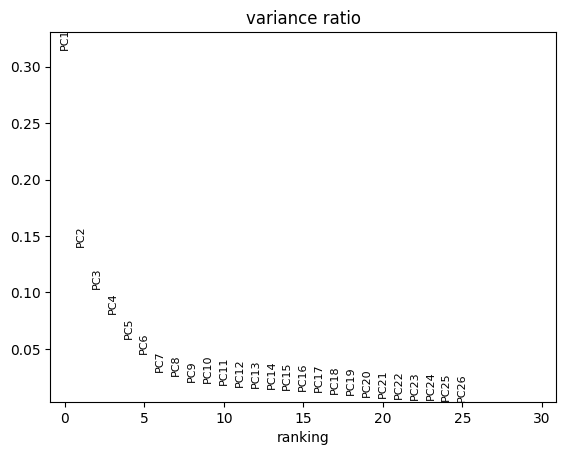

In [14]:
sc.tl.pca(sample, svd_solver="arpack")
sc.pl.pca_variance_ratio(sample, log=False)

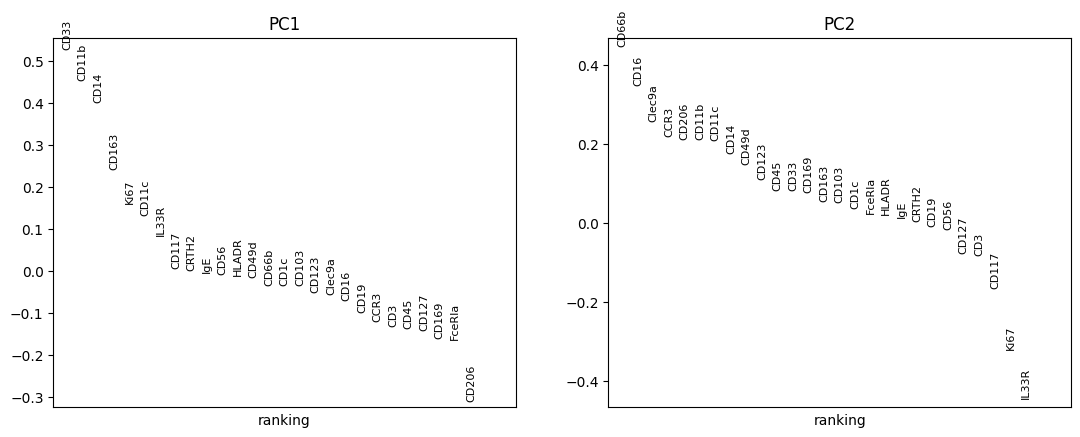

In [15]:
sc.pl.pca_loadings(sample, components = '1,2')

In [ ]:
bld_samples = bld_session.get_sample_ids()
bom_samples = bom_session.get_sample_ids()
jel_samples = jel_session.get_sample_ids()
jlp_samples = jlp_session.get_sample_ids()
lng_samples = lng_session.get_sample_ids()
lln_samples = lln_session.get_sample_ids()
mln_samples = mln_session.get_sample_ids()
spl_samples = spl_session.get_sample_ids()

In [17]:
sample_list = bld_samples + bom_samples
sample_list = list(set(sample_list))

In [18]:
from preprocessing import pca_df
grouped_pca = pca_df(sample, singular = False, sample_list=sample_list)

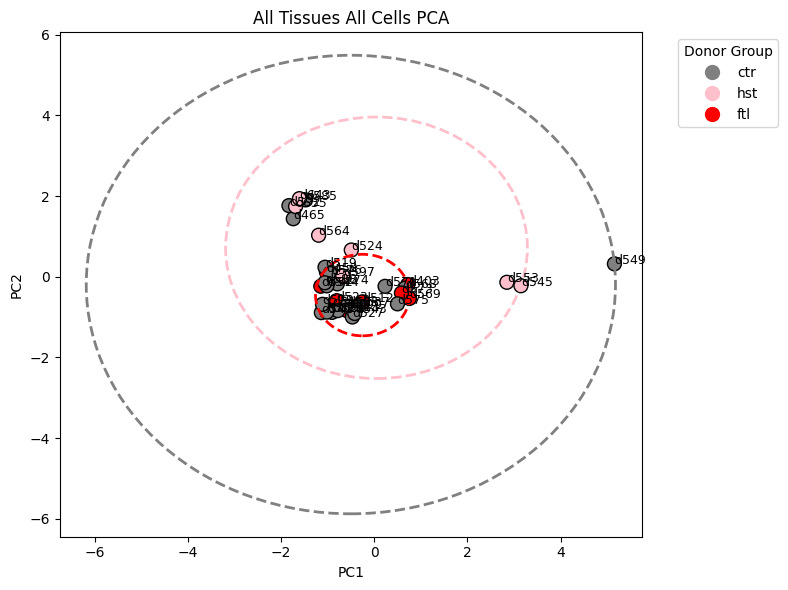

In [19]:
from plotting_methods import pca_plot
pca_plot(grouped_pca, tissue_type, sample_name)

In [54]:
adata_filtered.obs

,group,sample_id,tissue,batch
140560,ctr,d571,BLD,0
116331,ctr,d571,BLD,0
121585,ctr,d571,BLD,0
21684,ctr,d571,BLD,0
251367,ctr,d571,BLD,0
...,...,...,...,...
572642,ftl,d532,BOM,5
539444,ftl,d532,BOM,5
114121,ftl,d523,BOM,5
180125,ftl,d500,BOM,5


computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:28)
running Leiden clustering
    finished: found 17 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:05)
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


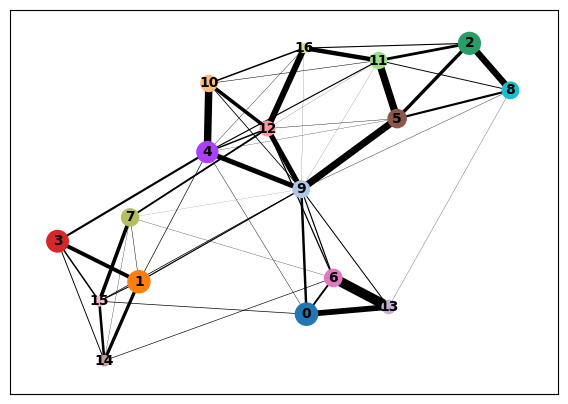

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)


In [ ]:
sc.external.pp.harmony_integrate(sample, key='sample_id', max_iter_harmony=20)
sc.pp.neighbors(sample, use_rep='X_pca_harmony')
sc.tl.umap(sample)

In [56]:
markers = list(sample.var_names)

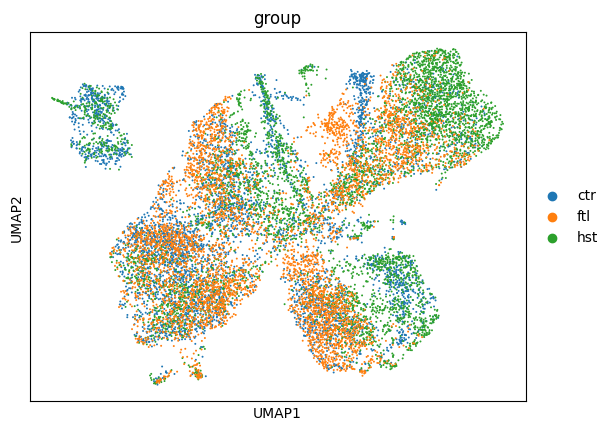

In [ ]:
sc.pl.umap(sample, color= ['group'], cmap='turbo', title = '{} {} Groups'.format(tissue_type, sample_name))

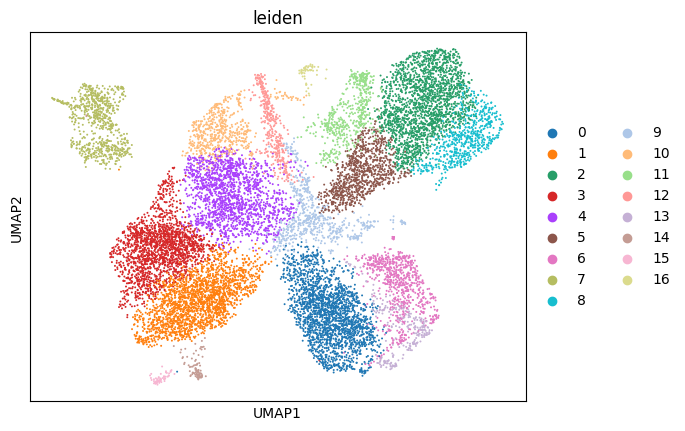

In [ ]:
sc.pl.umap(sample, color= ['leiden'], cmap='turbo', title = '{} {} Clusters'.format(tissue_type, sample_name))

/usr/local/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1154: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


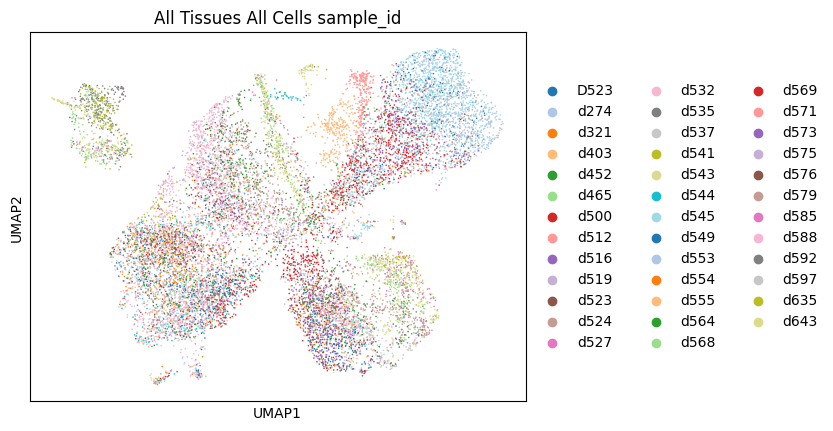

In [59]:
import seaborn as sns
import scanpy as sc

unique_samples = sample.obs['sample_id'].unique()
palette = sns.color_palette("tab20", n_colors=len(unique_samples))
sample.uns['sample_id_colors'] = [palette[i % len(palette)] for i in range(len(unique_samples))]
sc.pl.umap(sample, color='sample_id', size = 5, title='{} {} sample_id'.format(tissue_type, sample_name))


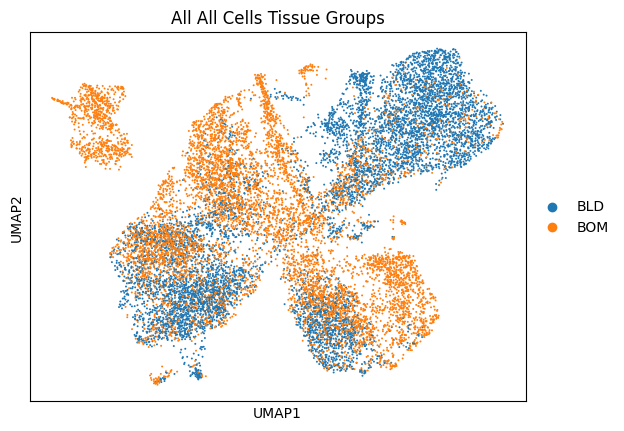

In [ ]:
sc.pl.umap(sample, color= ['tissue'], cmap='turbo', title = '{} Tissue Groups'.format(sample_name))

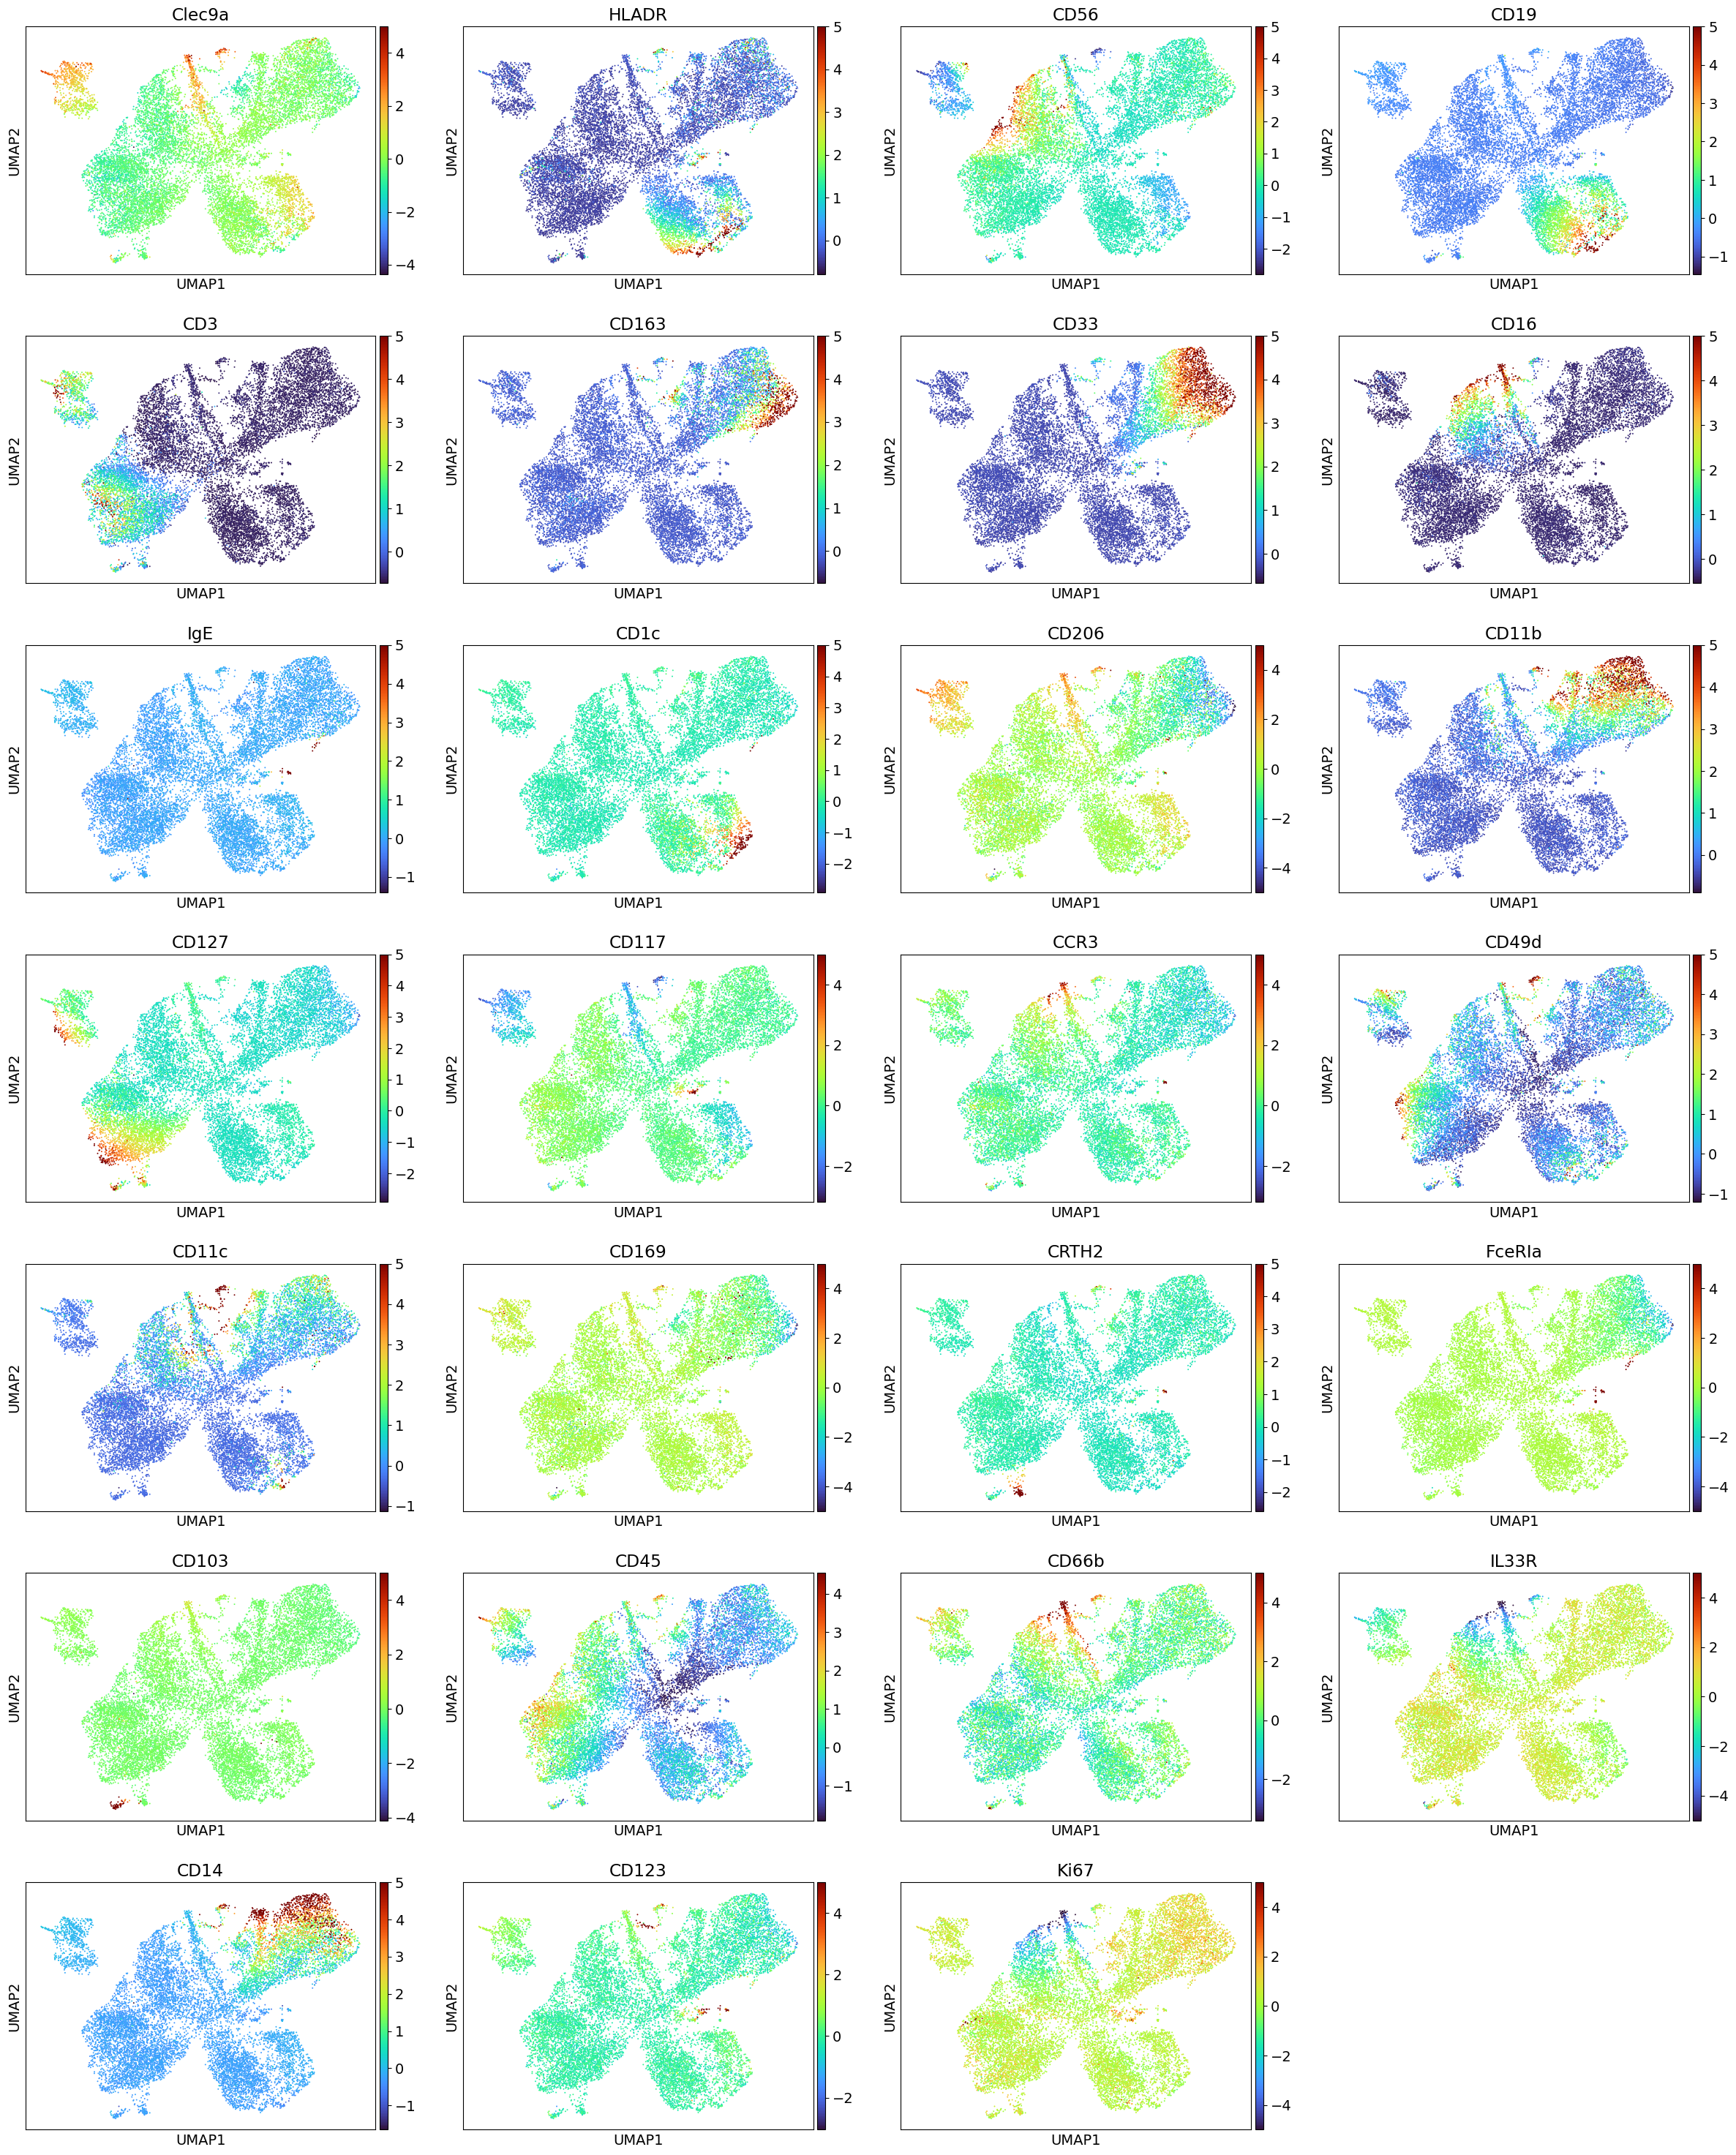

In [61]:
plt.rcParams.update({'font.size': 14})  
sc.pl.umap(sample, color=markers, cmap='turbo')

In [ ]:
sc.pl.dotplot(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Dotplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)

       leiden               celltype
140560     11  CD11c:CD11b:CD14 (11)
116331      0    CD19:HLADR:CD1c (0)
121585      3     CD45:CD3:CD117 (3)
21684      11  CD11c:CD11b:CD14 (11)
251367     11  CD11c:CD11b:CD14 (11)


In [ ]:
celltype = {'celltype': []}
cluster_to_genes = {


}
celltype['celltype'] = [cluster_to_genes[leiden] for leiden in sample.obs['leiden']]
sample.obs["celltype"] = celltype['celltype']

print(sample.obs[["leiden", "celltype"]].head())

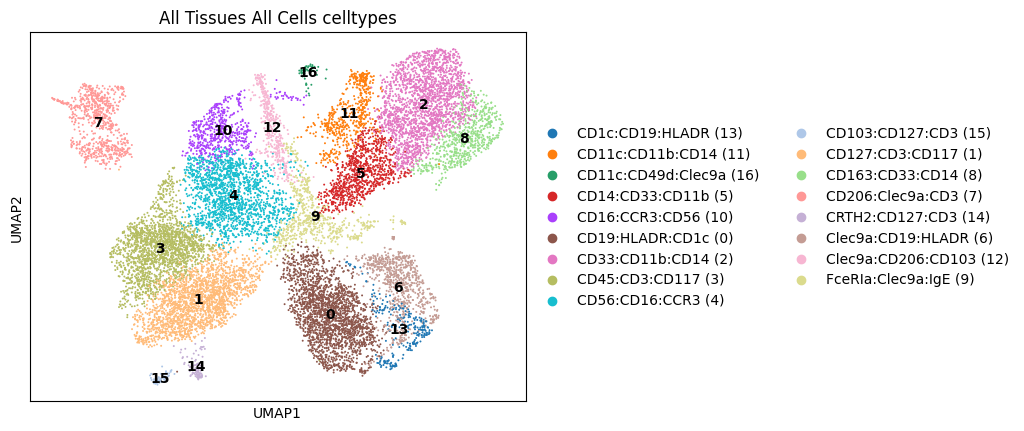

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pl.umap(
    sample,
    color=['celltype'],
    cmap='turbo',
    title = '{} {} celltypes'.format(tissue_type, sample_name),
    show=False,            
)

ax = plt.gca() 
for cluster in sample.obs['leiden'].cat.categories:
    cluster_mask = sample.obs['leiden'] == cluster
    cluster_coords = sample.obsm['X_umap'][cluster_mask]
    x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
    ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

plt.show()

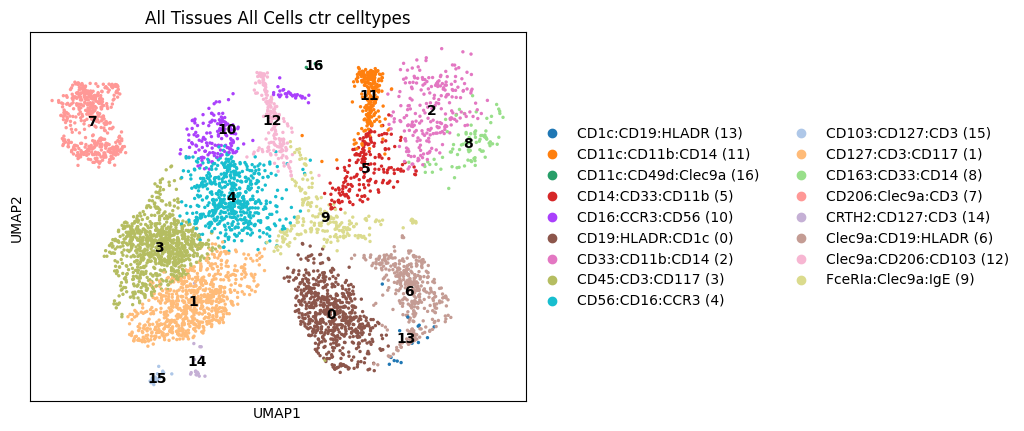

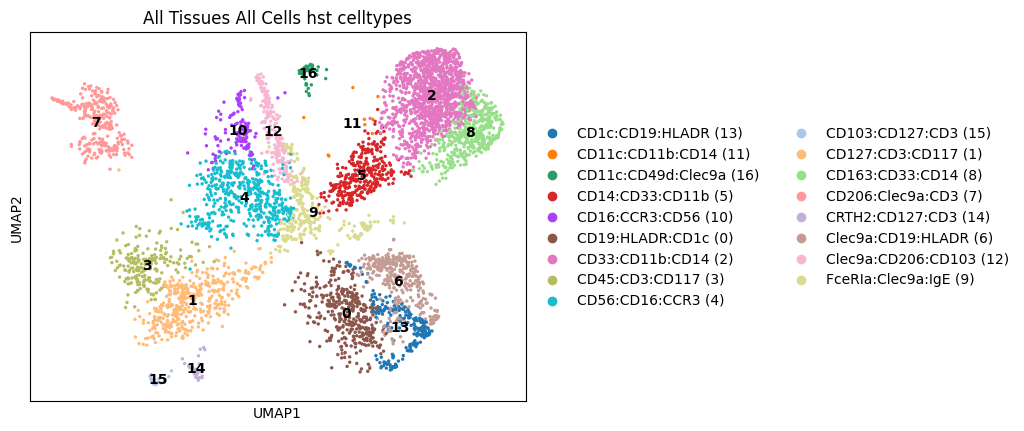

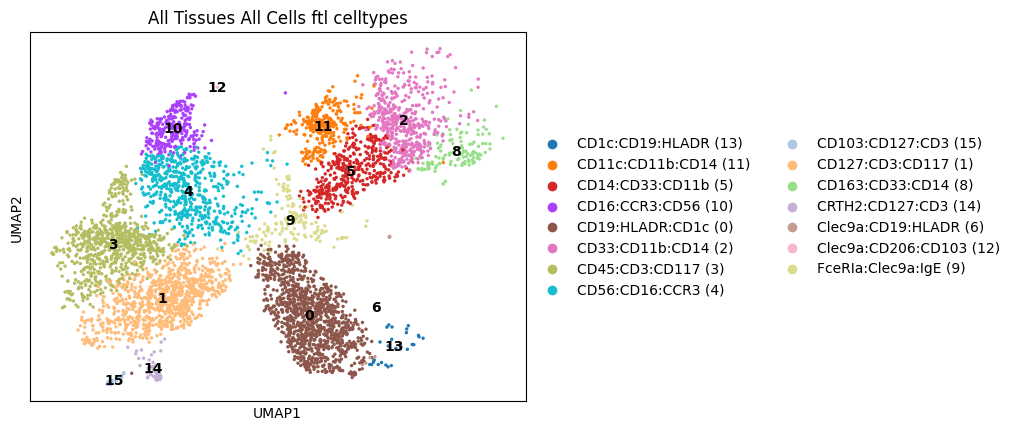

In [ ]:
for group in ['ctr', 'hst', 'ftl']:
    adata_group = sample[sample.obs['group'] == group]
    
    sc.pl.umap(
    adata_group,
    color=['celltype'],
    title=f'{tissue_type} {sample_name} {group} celltypes',
    cmap='turbo', 
    show=False             
)

    ax = plt.gca()  
    for cluster in adata_group.obs['leiden'].cat.categories:
        cluster_mask = adata_group.obs['leiden'] == cluster
        cluster_coords = adata_group.obsm['X_umap'][cluster_mask]
        x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
        ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

    plt.show()

In [70]:
plt.rcParams.update({'font.size': 12})  

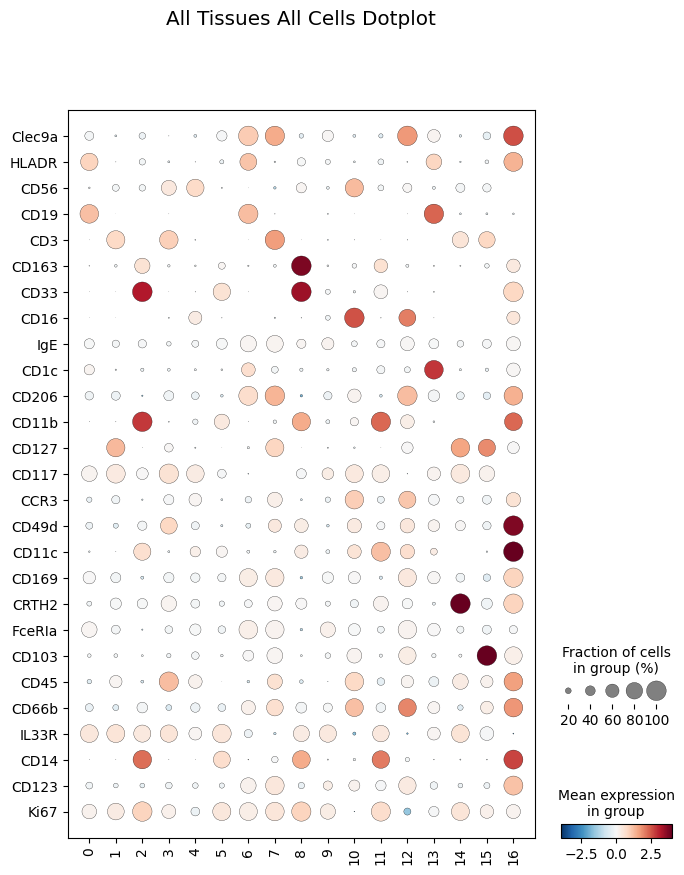

In [ ]:
sc.pl.dotplot(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Dotplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)

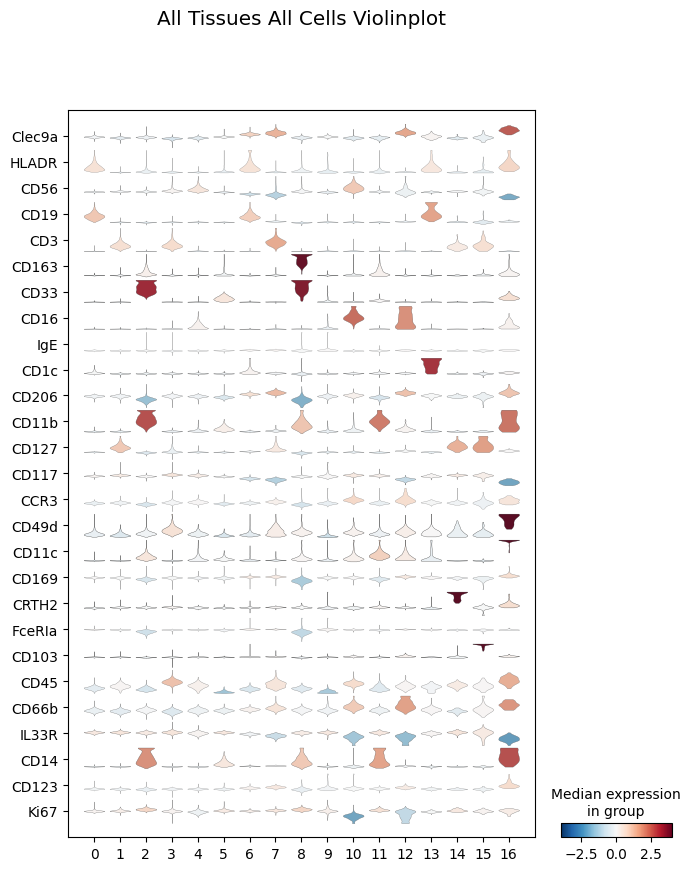

In [ ]:
sc.pl.stacked_violin(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Violinplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)